# HealthConnect Clinic — Week 5 Analysis Notebook

### AnalystLab Africa Experience Lab — Week 5: Solution Development & Implementation

**Track:** Data Analytics
**Prepared by:** Hillary Emmanuel
**Project:** HealthConnect Clinic Experience Lab (Improving Patient Appointment Attendance and Healthcare Support Using Data and AI)

This is the Initial HealthConnect Analytics Notebook, the Week 5 output for the Data Analytics track. It runs in the order the brief sets out:

1. Setup and data load
2. Data preparation: inspection, data quality, derived fields
3. Exploratory data analysis of attendance and no-show patterns
4. Confounding check, carried over from the Week 4 plan
5. KPI development for the five KPIs set in Week 4
6. Dashboard
7. Business insights
8. Business recommendations
9. Assumptions, limitations, risks and dependencies

The notebook reads `HealthConnect_Appointment_Data.csv` and `HealthConnect_Data_Dictionary.xlsx` from `../data/` read-only. The originals are never changed. Anything cleaned or derived is written separately to `../data/processed/`.

Developed on Python 3.14. Run `pip install -r requirements.txt` to reproduce the environment. No version-specific syntax is used.

## 1. Setup & data load

In [1]:
# Imports & display config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.2


In [2]:
# Paths — raw data is READ-ONLY; derived data goes to ../data/processed/
DATA_DIR      = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR    = Path("../outputs")
FIG_DIR       = OUTPUT_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_CSV   = DATA_DIR / "HealthConnect_Appointment_Data.csv"
DICT_XLSX = DATA_DIR / "HealthConnect_Data_Dictionary.xlsx"

print("raw csv exists :", RAW_CSV.exists())
print("data dict exists:", DICT_XLSX.exists())

raw csv exists : True
data dict exists: True


In [3]:
# Load raw data (read-only) — we never write back to RAW_CSV
appointments = pd.read_csv(RAW_CSV)
data_dict    = pd.read_excel(DICT_XLSX)

print(f"appointments: {appointments.shape[0]:,} rows x {appointments.shape[1]} columns")
appointments.head()

appointments: 5,000 rows x 18 columns


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [4]:
# Data dictionary — reference for every variable
data_dict

,Variable,Data Type,Description,Example,Notes
0,appointment_id,Text,Unique appointment identifier,HC-00001,Primary key
1,patient_id,Text,Anonymised patient identifier,P-0421,May appear across multiple appointments
2,gender,Text,Recorded gender category,Female,Synthetic and anonymised
3,age,Integer,Patient age in years,34,Adult patients only
4,age_group,Text,Age band derived from age,25-34,Provided for descriptive analysis
5,appointment_type,Text,Type of scheduled appointment,Follow-up,Four appointment categories
6,booking_date,Date,Date appointment was booked,2025-04-10 00:00:00,ISO format
7,appointment_date,Date,Scheduled appointment date,2025-04-24 00:00:00,ISO format
8,appointment_day,Text,Day of week for appointment,Thursday,Derived from appointment date
9,appointment_time,Text,Appointment time period,Morning,"Morning, Afternoon, Evening"


## 2. Data preparation

The brief asks for the data to be checked before any analysis: variable types, missing values, duplicates, inconsistent values, and the original file left untouched. Everything below runs on an in-memory copy, and the cleaned version is saved separately under `../data/processed/`.

Week 4 already found this dataset clean and internally consistent. This section checks that again on the Week 5 copy and writes down each test.

### 2.1 Structure and data types

In [5]:
# Work on a copy - the original `appointments` frame is left untouched
df = appointments.copy()

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   str    
 1   patient_id             5000 non-null   str    
 2   gender                 5000 non-null   str    
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   str    
 5   appointment_type       5000 non-null   str    
 6   booking_date           5000 non-null   str    
 7   appointment_date       5000 non-null   str    
 8   appointment_day        5000 non-null   str    
 9   appointment_time       5000 non-null   str    
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   str    
 14  reminder_channel       3634 non-null   str    
 15  distance_to_cli

In [6]:
# Compare loaded dtypes against the data dictionary's stated types
dict_types = data_dict.set_index("Variable")["Data Type"].to_dict()
type_check = pd.DataFrame({
    "loaded_dtype": df.dtypes.astype(str),
    "dictionary_type": pd.Series(dict_types),
})
type_check


,loaded_dtype,dictionary_type
appointment_id,str,Text
patient_id,str,Text
gender,str,Text
age,int64,Integer
age_group,str,Text
appointment_type,str,Text
booking_date,str,Date
appointment_date,str,Date
appointment_day,str,Text
appointment_time,str,Text


`booking_date` and `appointment_date` come in as text rather than dates. They are stored as `M/D/YYYY` strings even though the dictionary example uses ISO format, and Section 2.6 parses them. `waiting_time_minutes` reads as a float only because the missing values force it; the actual values are all whole numbers, so it is really an integer, and the dictionary agrees. Everything else matches the dictionary.

### 2.2 Missing values

In [7]:
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
})
missing[missing.n_missing > 0]


,n_missing,pct_missing
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


In [8]:
# Is reminder_channel missing STRUCTURALLY (i.e. only when no reminder was sent)?
structural = df.loc[df.reminder_channel.isna(), "reminder_sent"].value_counts()
print("reminder_sent value when reminder_channel is missing:")
print(structural)
print()
print("reminder_sent == 'No' count overall:", (df.reminder_sent == "No").sum())


reminder_sent value when reminder_channel is missing:
reminder_sent
No    1366
Name: count, dtype: int64

reminder_sent == 'No' count overall: 1366


Three columns have missing values. Only two of them are real gaps.

| Column | Missing | % | Nature |
|---|---|---|---|
| `reminder_channel` | 1,366 | 27.3% | Structural, not a defect. Missing only when `reminder_sent == "No"` (1,366 = 1,366, exact match). The dictionary says the channel is "None when no reminder was sent." Filled with the label `"None"` rather than treated as unknown. |
| `distance_to_clinic_km` | 90 | 1.80% | Genuine missing data. Feeds KPI 3 (distance bands). |
| `waiting_time_minutes` | 60 | 1.20% | Genuine missing data. A weak separator in Week 4, so lower priority. |

The decision here is carried over from the Week 4 plan. The roughly 1.8% of rows with no `distance_to_clinic_km` are left out of distance analysis rather than filled in, so no invented values get into a variable that genuinely predicts no-shows. A `distance_known` flag makes it clear those KPIs run on about 98% of appointments. `waiting_time_minutes` is handled the same way if it is used at all.

### 2.3 Duplicates

In [9]:
print("Fully duplicated rows:          ", df.duplicated().sum())
print("Duplicated appointment_id (PK):  ", df.appointment_id.duplicated().sum())
print()
print("Distinct patients:", df.patient_id.nunique(), "across", len(df), "appointments")
print("-> patients recur across appointments by design (patient_id is not unique per row);")
print("   the data dictionary confirms a patient 'may appear across multiple appointments'.")


Fully duplicated rows:           0
Duplicated appointment_id (PK):   0

Distinct patients: 1696 across 5000 appointments
-> patients recur across appointments by design (patient_id is not unique per row);
   the data dictionary confirms a patient 'may appear across multiple appointments'.


No duplicate rows and no repeated `appointment_id`. `patient_id` does repeat across rows (1,696 patients across 5,000 appointments), which the dictionary says to expect and is not a duplication problem. It does mean the rows are not fully independent of each other, which Section 9 lists as a limitation.

### 2.4 Categorical values — consistency

In [10]:
cat_cols = ["gender", "age_group", "appointment_type", "appointment_day",
            "appointment_time", "reminder_sent", "reminder_channel", "appointment_outcome"]
for c in cat_cols:
    vals = df[c].dropna().unique()
    stray_ws = [v for v in vals if isinstance(v, str) and v != v.strip()]
    print(f"{c:22s} {len(vals):2d} distinct | stray whitespace: {stray_ws if stray_ws else 'none'}")
    print(f"{'':22s} {sorted(map(str, vals))}")
    print()


gender                  3 distinct | stray whitespace: none
                       ['Female', 'Male', 'Prefer not to say']

age_group               6 distinct | stray whitespace: none
                       ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

appointment_type        4 distinct | stray whitespace: none
                       ['Diagnostic Test', 'Follow-up', 'General Consultation', 'Specialist Consultation']

appointment_day         7 distinct | stray whitespace: none
                       ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']

appointment_time        3 distinct | stray whitespace: none
                       ['Afternoon', 'Evening', 'Morning']

reminder_sent           2 distinct | stray whitespace: none
                       ['No', 'Yes']

reminder_channel        3 distinct | stray whitespace: none
                       ['Email', 'SMS', 'WhatsApp']

appointment_outcome     3 distinct | stray whitespace: none
                 

Every categorical column uses a small, fixed vocabulary. No casing variants, no stray whitespace, no unexpected categories. `appointment_outcome` has exactly the three documented classes: Attended, No-Show, Cancelled.

### 2.5 Numeric ranges and cross-field logic

In [11]:
num_cols = ["age", "booking_lead_days", "previous_appointments",
            "previous_no_shows", "distance_to_clinic_km", "waiting_time_minutes"]
df[num_cols].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
age,5000.0,48.79,18.14,18.0,33.0,49.0,64.0,80.0
booking_lead_days,5000.0,29.64,17.40,0.0,15.0,30.0,45.0,60.0
previous_appointments,5000.0,3.01,1.74,0.0,2.0,3.0,4.0,11.0
previous_no_shows,5000.0,0.54,0.75,0.0,0.0,0.0,1.0,5.0
distance_to_clinic_km,4910.0,10.11,6.59,0.5,5.3,8.7,13.5,45.0
waiting_time_minutes,4940.0,24.19,10.86,2.0,17.0,24.0,32.0,68.0


In [12]:
# Logical integrity checks
bd = pd.to_datetime(df.booking_date, format="%m/%d/%Y")
ad = pd.to_datetime(df.appointment_date, format="%m/%d/%Y")

checks = {
    "previous_no_shows > previous_appointments":      (df.previous_no_shows > df.previous_appointments).sum(),
    "negative booking_lead_days":                     (df.booking_lead_days < 0).sum(),
    "age outside adult range (<18 or >100)":          ((df.age < 18) | (df.age > 100)).sum(),
    "age_group inconsistent with age":                (pd.cut(df.age, [18,25,35,45,55,65,200], right=False,
                                                        labels=['18-24','25-34','35-44','45-54','55-64','65+'])
                                                        .astype(str) != df.age_group).sum(),
    "booking_date after appointment_date":            (bd > ad).sum(),
    "booking_lead_days != (appointment - booking)":   ((ad - bd).dt.days != df.booking_lead_days).sum(),
    "appointment_day != weekday(appointment_date)":   (ad.dt.day_name() != df.appointment_day).sum(),
    "reminder_sent='No' but channel populated":       ((df.reminder_sent == "No") & df.reminder_channel.notna()).sum(),
    "reminder_sent='Yes' but channel missing":        ((df.reminder_sent == "Yes") & df.reminder_channel.isna()).sum(),
}
pd.Series(checks, name="rows_violating").to_frame()


,rows_violating
previous_no_shows > previous_appointments,0
negative booking_lead_days,0
age outside adult range (<18 or >100),0
age_group inconsistent with age,0
booking_date after appointment_date,0
booking_lead_days != (appointment - booking),0
appointment_day != weekday(appointment_date),0
reminder_sent='No' but channel populated,0
reminder_sent='Yes' but channel missing,0


Every logical check returns zero.

- `previous_no_shows` never exceeds `previous_appointments`, which is the dictionary's stated rule.
- `booking_lead_days` equals `appointment_date` minus `booking_date` for all 5,000 rows.
- `appointment_day` matches the actual weekday of `appointment_date` for every row.
- `age_group` lines up with `age` for every row, and all patients are adults (18 to 80).
- `reminder_channel` is filled in exactly when a reminder was sent, and blank otherwise.

The numeric ranges are all sensible: `booking_lead_days` 0 to 60, `previous_no_shows` 0 to 5, `distance_to_clinic_km` 0.5 to 45.0 km, `waiting_time_minutes` 2 to 68. Appointment dates run from 2025-01-01 to 2026-06-30. The future dates confirm this is synthetic training data, which is a limitation rather than an error.

This matches the Week 4 conclusion: the dataset is clean and internally consistent.

### 2.6 Build the analysis frame

Now the fields the KPIs and EDA need. Nothing is dropped. The original columns stay and new ones are added:

- `booking_date`, `appointment_date` parsed to real dates
- `reminder_channel` blanks filled with `"None"` (structural)
- `is_no_show`, a true/false target for rate calculations (`appointment_outcome == "No-Show"`)
- `distance_known`, a flag so distance analysis can be shown as running on 98% of rows
- `prior_no_show_bracket`, `lead_time_band`, `distance_band`, the segments for KPIs 1 to 3

In [13]:
analysis = df.copy()

# Parse dates
analysis["booking_date"]     = pd.to_datetime(analysis["booking_date"], format="%m/%d/%Y")
analysis["appointment_date"] = pd.to_datetime(analysis["appointment_date"], format="%m/%d/%Y")

# Structural fill
analysis["reminder_channel"] = analysis["reminder_channel"].fillna("None")

# Target + data-availability flag
analysis["is_no_show"]     = analysis["appointment_outcome"].eq("No-Show")
analysis["distance_known"] = analysis["distance_to_clinic_km"].notna()

# --- Segment bands for KPIs 1-3 ---
analysis["prior_no_show_bracket"] = pd.cut(
    analysis["previous_no_shows"], bins=[-1, 0, 1, 2, 99],
    labels=["0", "1", "2", "3+"],
)

analysis["lead_time_band"] = pd.cut(
    analysis["booking_lead_days"], bins=[-1, 7, 14, 30, 45, 60],
    labels=["0-7 days", "8-14 days", "15-30 days", "31-45 days", "46-60 days"],
)

analysis["distance_band"] = pd.cut(
    analysis["distance_to_clinic_km"], bins=[0, 5, 10, 15, 100],
    labels=["<5 km", "5-10 km", "10-15 km", "15+ km"],
)  # NaN where distance is missing - intended

print("New columns added:", ["booking_date(parsed)", "appointment_date(parsed)",
      "is_no_show", "distance_known", "prior_no_show_bracket", "lead_time_band", "distance_band"])
print("\nSegment band sizes (watch for small cells):")
for col in ["prior_no_show_bracket", "lead_time_band", "distance_band"]:
    print(f"\n{col}:")
    print(analysis[col].value_counts(dropna=False).sort_index())


New columns added: ['booking_date(parsed)', 'appointment_date(parsed)', 'is_no_show', 'distance_known', 'prior_no_show_bracket', 'lead_time_band', 'distance_band']

Segment band sizes (watch for small cells):

prior_no_show_bracket:
prior_no_show_bracket
0     2921
1     1548
2      438
3+      93
Name: count, dtype: int64

lead_time_band:
lead_time_band
0-7 days       640
8-14 days      602
15-30 days    1333
31-45 days    1258
46-60 days    1167
Name: count, dtype: int64

distance_band:
distance_band
<5 km       1156
5-10 km     1692
10-15 km    1132
15+ km       930
NaN           90
Name: count, dtype: int64


Week 4 flagged that the extreme rates at the tail of `previous_no_shows` (value = 5, for example) come from very few rows. Grouping `2` and `3+` keeps each segment big enough to read while still isolating the high-risk patients. Any segment that is still thin gets called out where it comes up in Section 5.

### 2.7 Save the processed dataset (original left untouched)

In [14]:
PROCESSED_PATH = PROCESSED_DIR / "healthconnect_appointments_prepared.csv"
analysis.to_csv(PROCESSED_PATH, index=False)

print("Saved:", PROCESSED_PATH.resolve())
print("Rows :", len(analysis), "| Columns:", analysis.shape[1])
print("Original CSV untouched:", RAW_CSV.stat().st_size, "bytes,",
      "still", pd.read_csv(RAW_CSV).shape, "shape")


Saved: C:\Users\hilla\OneDrive\Desktop\AnalystLab\week 5\data\processed\healthconnect_appointments_prepared.csv
Rows : 5000 | Columns: 23
Original CSV untouched: 590861 bytes, still (5000, 18) shape


### 2.7b Sort-order helper columns (for Power BI)

pandas already knows the right order of `lead_time_band` and `distance_band` because `pd.cut` built them, so it keeps "0-7 days" before "8-14 days" internally. Once the table is saved as a plain CSV and opened somewhere else, that order is lost. Power BI just sees text and sorts it alphabetically, which lands "8-14 days" after "46-60 days" (because "8" sorts after "4") and pushes "<5 km" to the end (because "<" sorts after digits). That would scramble the KPI 2 and KPI 3 charts.

The fix is a small whole-number column next to each band, `lead_time_band_order` and `distance_band_order`, that Power BI can sort by instead of the text. The labels themselves do not change.

In [15]:
lead_order_map = {
    "0-7 days": 1, "8-14 days": 2, "15-30 days": 3, "31-45 days": 4, "46-60 days": 5,
}
distance_order_map = {
    "<5 km": 1, "5-10 km": 2, "10-15 km": 3, "15+ km": 4,
}
bracket_order_map = {
    "0": 1, "1": 2, "2": 3, "3+": 4,
}

analysis_for_export = pd.read_csv(PROCESSED_PATH)
analysis_for_export["lead_time_band_order"]       = analysis_for_export["lead_time_band"].map(lead_order_map)
analysis_for_export["distance_band_order"]        = analysis_for_export["distance_band"].map(distance_order_map)
analysis_for_export["prior_no_show_bracket_order"] = analysis_for_export["prior_no_show_bracket"].map(bracket_order_map)

analysis_for_export.to_csv(PROCESSED_PATH, index=False)

print("Re-saved with sort-order columns:", PROCESSED_PATH.resolve())
analysis_for_export[["lead_time_band", "lead_time_band_order",
                      "distance_band", "distance_band_order",
                      "prior_no_show_bracket", "prior_no_show_bracket_order"]].drop_duplicates().sort_values(
    ["lead_time_band_order"]).reset_index(drop=True)


Re-saved with sort-order columns: C:\Users\hilla\OneDrive\Desktop\AnalystLab\week 5\data\processed\healthconnect_appointments_prepared.csv


,lead_time_band,lead_time_band_order,distance_band,distance_band_order,prior_no_show_bracket,prior_no_show_bracket_order
0,0-7 days,1,10-15 km,3.0,0,1
1,0-7 days,1,10-15 km,3.0,3+,4
2,0-7 days,1,5-10 km,2.0,0,1
3,0-7 days,1,<5 km,1.0,0,1
4,0-7 days,1,10-15 km,3.0,2,3
...,...,...,...,...,...,...
92,46-60 days,5,NaN,NaN,2,3
93,46-60 days,5,15+ km,4.0,3+,4
94,46-60 days,5,10-15 km,3.0,3+,4
95,46-60 days,5,NaN,NaN,0,1


In Power BI: click the `lead_time_band` column in the Fields pane, go to the Column tools ribbon, choose Sort by column, and pick `lead_time_band_order`. Do the same for `distance_band` and `prior_no_show_bracket` if they do not already sort correctly. Set once per column, and every chart that uses them as an axis sorts right.

### 2.8 Data preparation summary

**Dataset.** 5,000 appointment records, 18 original variables, 1,696 distinct patients. Appointment dates run from 2025-01-01 to 2026-06-30 (synthetic, future-dated).

**Data types.** All match the dictionary except the two date columns, stored as `M/D/YYYY` text and now parsed, and `waiting_time_minutes`, which is float-typed only because of its missing values and is really an integer.

**Missing values.** Three columns, two of them genuine:
- `reminder_channel`: 27.3% missing but structural, missing exactly when no reminder was sent. Filled with `"None"`.
- `distance_to_clinic_km`: 1.80% genuine missing. Excluded from distance analysis rather than imputed, via the `distance_known` flag.
- `waiting_time_minutes`: 1.20% genuine missing. Low priority, a weak separator in Week 4.

**Duplicates.** None. No repeated `appointment_id`. `patient_id` recurs across rows by design.

**Consistency.** Every categorical column uses a clean fixed vocabulary. Every cross-field check returns zero violations: prior no-shows never exceed prior appointments, lead days equal the date difference, the weekday label matches the real weekday, the age band matches the age, and the reminder channel is present exactly when a reminder was sent.

**Derived fields.** `is_no_show` (target), `distance_known`, and the three segment bands `prior_no_show_bracket`, `lead_time_band`, `distance_band` for KPIs 1 to 3.

**Output.** `../data/processed/healthconnect_appointments_prepared.csv`. The original `HealthConnect_Appointment_Data.csv` is never modified.

## 3. Exploratory data analysis: attendance and no-show patterns

For each group of appointments, say the ones booked 46 to 60 days ahead, the question is what fraction ended in a no-show. That fraction is the no-show rate. If the rate barely moves between groups, the variable does not matter much. If it moves a lot, the variable is a real signal.

The overall no-show rate across all 5,000 appointments is the baseline that every group gets compared against.

In [16]:
analysis = pd.read_csv(PROCESSED_PATH)
analysis["is_no_show"] = analysis["is_no_show"].astype(bool)

overall_rate = analysis["is_no_show"].mean()
print(f"Overall no-show rate: {overall_rate:.1%}")
print()
print("Full outcome mix:")
print(analysis["appointment_outcome"].value_counts(normalize=True).round(3))


Overall no-show rate: 48.5%

Full outcome mix:
appointment_outcome
No-Show      0.485
Attended     0.463
Cancelled    0.053
Name: proportion, dtype: float64


The baseline is 48.5%. Almost a coin flip: nearly half of every booked slot goes unused. 46.3% are attended and 5.3% are properly cancelled, meaning the patient told the clinic in advance.

The next eight checks compare groups against that 48.5%. A group well above it is higher-risk, a group well below is lower-risk, and a group sitting near it tells us little.

### 3.1 Appointment characteristics: type, day, time

Does the kind of appointment, the day of the week, or the time of day change how likely someone is to miss it?

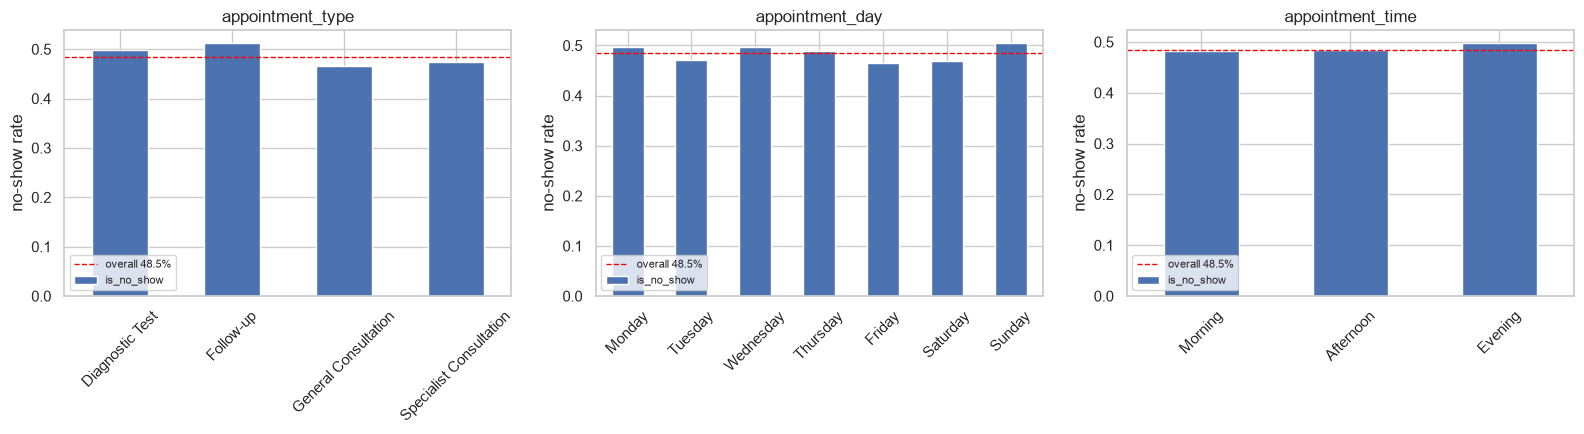

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col, order in [
    (axes[0], "appointment_type", None),
    (axes[1], "appointment_day", ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]),
    (axes[2], "appointment_time", ["Morning","Afternoon","Evening"]),
]:
    rates = analysis.groupby(col, observed=True)["is_no_show"].mean()
    if order:
        rates = rates.reindex(order)
    rates.plot(kind="bar", ax=ax, color="#4C72B0")
    ax.axhline(overall_rate, color="red", linestyle="--", linewidth=1, label=f"overall {overall_rate:.1%}")
    ax.set_ylabel("no-show rate")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_appointment_characteristics.png", dpi=150)
plt.show()


Every bar sits close to the red baseline line. The highest (Follow-up, around 51%) and the lowest (General Consultation, around 47%) are only four or five points apart. So appointment type, day, and time barely matter. This matches Week 4, where the appointment logistics were set aside.

### 3.2 Patient characteristics: gender, age group

Are some patient groups more likely to miss appointments than others?

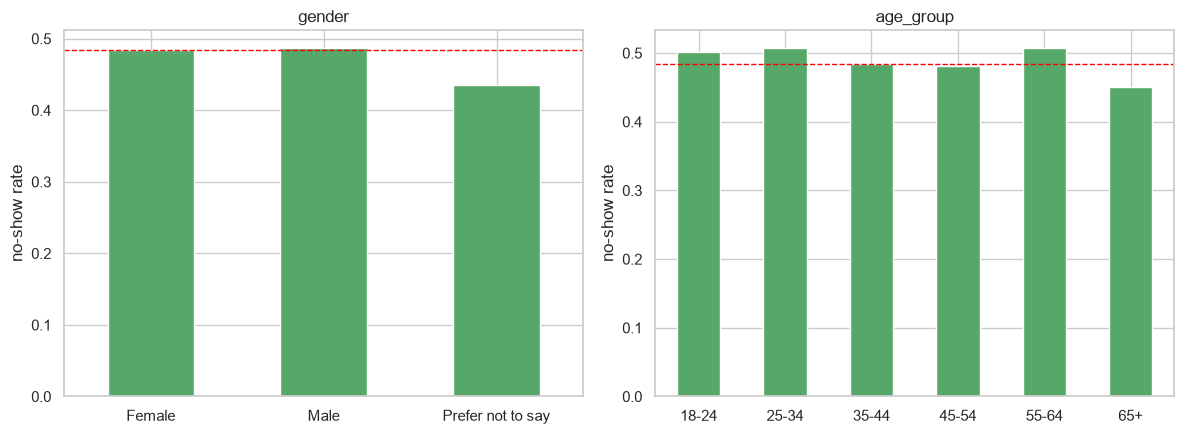

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

age_order = ["18-24","25-34","35-44","45-54","55-64","65+"]

analysis.groupby("gender", observed=True)["is_no_show"].mean().plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].axhline(overall_rate, color="red", linestyle="--", linewidth=1)
axes[0].set_title("gender"); axes[0].set_ylabel("no-show rate"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

analysis.groupby("age_group", observed=True)["is_no_show"].mean().reindex(age_order).plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].axhline(overall_rate, color="red", linestyle="--", linewidth=1)
axes[1].set_title("age_group"); axes[1].set_ylabel("no-show rate"); axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_patient_characteristics.png", dpi=150)
plt.show()


Again, every bar hugs the baseline. The widest gap across all the gender and age groups is about six points, with patients 65 and over slightly less likely to miss. Gender and age do not predict no-shows in any useful way here. This also matches Week 4.

### 3.3 Previous appointment history

If a patient has missed appointments before, are they more likely to miss the next one? Week 4 called this the strongest signal in the dataset.

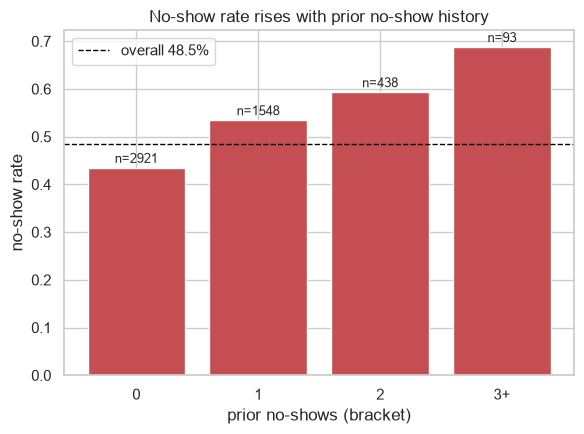

                       no_show_rate  n_appointments
prior_no_show_bracket                              
0                             0.435            2921
1                             0.535            1548
2                             0.594             438
3+                            0.688              93


In [19]:
fig, ax = plt.subplots(figsize=(6, 4.5))
order = ["0", "1", "2", "3+"]
rates = analysis.groupby("prior_no_show_bracket", observed=True)["is_no_show"].mean().reindex(order)
counts = analysis.groupby("prior_no_show_bracket", observed=True)["is_no_show"].count().reindex(order)

bars = ax.bar(order, rates, color="#C44E52")
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"overall {overall_rate:.1%}")
for bar, c in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"n={c}", ha="center", fontsize=9)
ax.set_ylabel("no-show rate")
ax.set_xlabel("prior no-shows (bracket)")
ax.set_title("No-show rate rises with prior no-show history")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_prior_no_shows.png", dpi=150)
plt.show()

print(pd.DataFrame({"no_show_rate": rates.round(3), "n_appointments": counts}))


This one is a staircase rather than a flat line. Patients with no prior no-shows miss 43.5% of the time. Patients with three or more miss 68.8% of the time. That 25-point gap is the biggest we have seen so far, and a patient's own history is clearly a real signal. The "3+" group is small at 93 appointments, so the exact figure needs more data before it is treated as fixed, but the climb through 0, 1, 2, 3+ is steady and consistent.

### 3.4 Reminders

Does sending a reminder actually stop people missing their appointment? The business scenario assumes reminders help a lot. Week 4 found that this does not really hold, so here is the direct check.

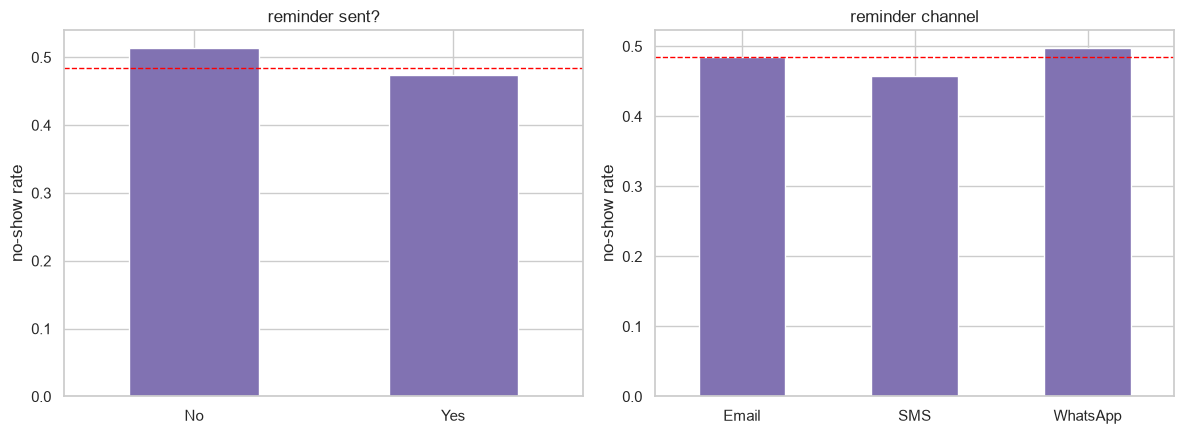

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

analysis.groupby("reminder_sent", observed=True)["is_no_show"].mean().reindex(["No","Yes"]).plot(
    kind="bar", ax=axes[0], color="#8172B2")
axes[0].axhline(overall_rate, color="red", linestyle="--", linewidth=1)
axes[0].set_title("reminder sent?"); axes[0].set_ylabel("no-show rate"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

analysis.groupby("reminder_channel", observed=True)["is_no_show"].mean().plot(
    kind="bar", ax=axes[1], color="#8172B2")
axes[1].axhline(overall_rate, color="red", linestyle="--", linewidth=1)
axes[1].set_title("reminder channel"); axes[1].set_ylabel("no-show rate"); axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_reminders.png", dpi=150)
plt.show()


Sending any reminder brings the no-show rate down from 51.4% to 47.4%. Real, but only four points, not the large drop you would expect if reminders were the main lever. Across channels, SMS looks slightly better (45.8%) than WhatsApp (49.8%), but those are close too. Reminders have a small genuine effect, worth keeping, but not a fix for the no-show problem on their own. This matches Week 4, now with the numbers behind it.

### 3.5 Waiting time

Does how long someone waits at the clinic relate to whether they showed up? Waiting time is only recorded for appointments that were attended, so the question here is whether its distribution looks sensible and whether it varies by outcome at all.

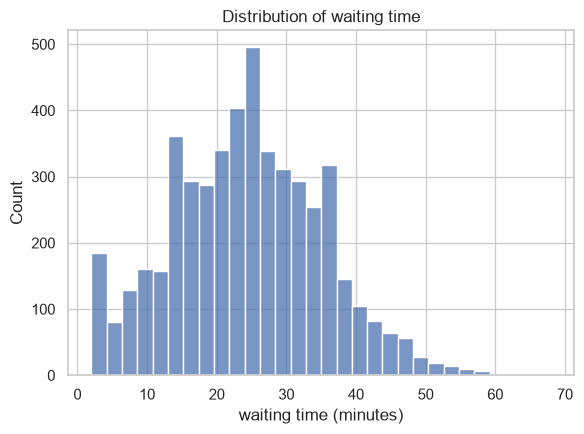

count    4940.0
mean       24.2
std        10.9
min         2.0
25%        17.0
50%        24.0
75%        32.0
max        68.0
Name: waiting_time_minutes, dtype: float64


In [21]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.histplot(analysis["waiting_time_minutes"].dropna(), bins=30, ax=ax, color="#4C72B0")
ax.set_xlabel("waiting time (minutes)")
ax.set_title("Distribution of waiting time")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_waiting_time.png", dpi=150)
plt.show()

print(analysis["waiting_time_minutes"].describe().round(1))


A fairly ordinary bell-shaped spread, centred near 24 minutes, mostly between 17 and 32, with a longish tail out to 68. Nothing unusual or broken. Week 4 had already set this variable aside because it barely separated the outcomes, and this distribution gives no reason to revisit that. It is stored and clean, but the signal is not here.

### 3.6 Distance to clinic

Do patients who live further away miss more appointments? Week 4 listed this as one of the three strongest variables.

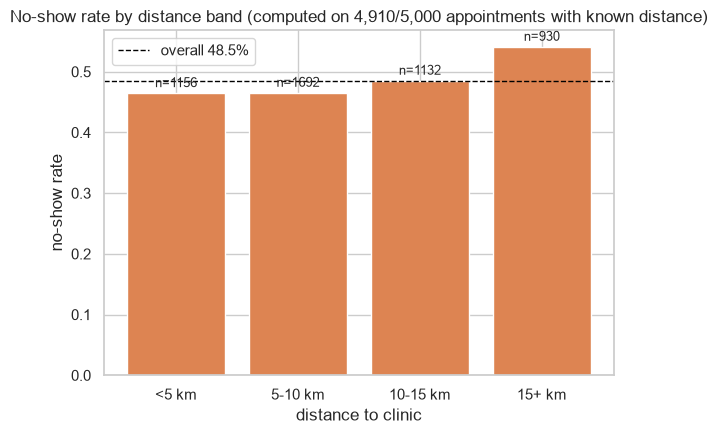

               no_show_rate  n_appointments
distance_band                              
<5 km                 0.465            1156
5-10 km               0.465            1692
10-15 km              0.485            1132
15+ km                0.541             930


In [22]:
fig, ax = plt.subplots(figsize=(6, 4.5))
order = ["<5 km", "5-10 km", "10-15 km", "15+ km"]
known = analysis[analysis["distance_known"]]
rates = known.groupby("distance_band", observed=True)["is_no_show"].mean().reindex(order)
counts = known.groupby("distance_band", observed=True)["is_no_show"].count().reindex(order)

bars = ax.bar(order, rates, color="#DD8452")
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"overall {overall_rate:.1%}")
for bar, c in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"n={c}", ha="center", fontsize=9)
ax.set_ylabel("no-show rate")
ax.set_xlabel("distance to clinic")
ax.set_title(f"No-show rate by distance band (computed on {known.shape[0]:,}/{analysis.shape[0]:,} appointments with known distance)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_distance.png", dpi=150)
plt.show()

print(pd.DataFrame({"no_show_rate": rates.round(3), "n_appointments": counts}))


The first three bars, from under 5 km through 10 to 15 km, are almost identical and sit near the 46 to 49% baseline. Only the farthest group, 15+ km, stands out at 54.1%, about six to eight points above the rest. So distance matters, but as a "too far" effect rather than a smooth slope. Nearby and mid-distance patients behave almost the same, and only the far group is genuinely different. It is a real signal, just weaker than prior history.

### 3.7 Booking lead time

Does booking far in advance change the chance of a no-show? Week 4 listed this as the other strong variable, with a hunch that there might be a point where the risk jumps.

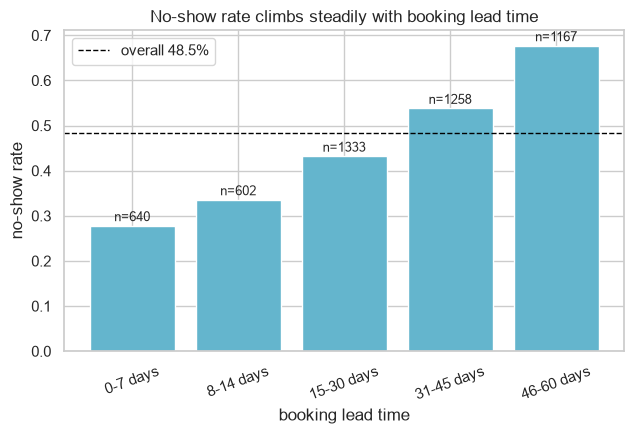

                no_show_rate  n_appointments
lead_time_band                              
0-7 days               0.278             640
8-14 days              0.336             602
15-30 days             0.432            1333
31-45 days             0.538            1258
46-60 days             0.677            1167


In [23]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
order = ["0-7 days", "8-14 days", "15-30 days", "31-45 days", "46-60 days"]
rates = analysis.groupby("lead_time_band", observed=True)["is_no_show"].mean().reindex(order)
counts = analysis.groupby("lead_time_band", observed=True)["is_no_show"].count().reindex(order)

bars = ax.bar(order, rates, color="#64B5CD")
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"overall {overall_rate:.1%}")
for bar, c in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"n={c}", ha="center", fontsize=9)
ax.set_ylabel("no-show rate")
ax.set_xlabel("booking lead time")
ax.set_title("No-show rate climbs steadily with booking lead time")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_lead_time.png", dpi=150)
plt.show()

print(pd.DataFrame({"no_show_rate": rates.round(3), "n_appointments": counts}))


This is the clearest staircase in the dataset. Booked within a week, only 27.8% are missed. Booked 46 to 60 days ahead, 67.7% are missed. A 40-point swing, more than double the risk, and it climbs through every band in between: 27.8%, 33.6%, 43.2%, 53.8%, 67.7%. No jump, no plateau, just a steady slope. Booking lead time is the single strongest predictor of a no-show here. A patient booked far ahead has more time to forget, lose interest, or have their circumstances change before the date comes round.

### 3.8 Cancellations vs no-shows

Week 4 argued that a cancellation, where the patient warns the clinic in advance, and a no-show, where they just do not turn up, are different things and should never be counted as one outcome. This checks whether the data supports keeping them apart.

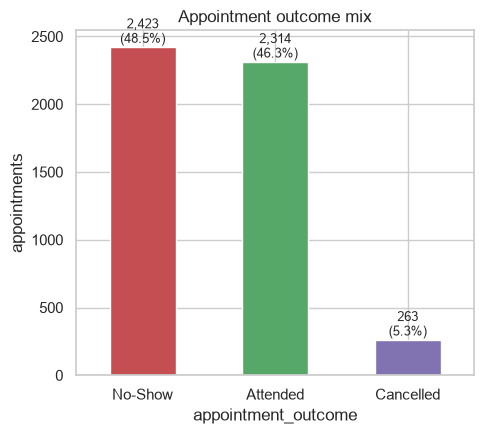

appointment_outcome  Cancelled  No-Show
lead_time_band                         
0-7 days                    36      178
15-30 days                  68      576
31-45 days                  71      677
46-60 days                  60      790
8-14 days                   28      202


In [24]:
fig, ax = plt.subplots(figsize=(5, 4.5))
mix = analysis["appointment_outcome"].value_counts()
mix.plot(kind="bar", ax=ax, color=["#C44E52", "#55A868", "#8172B2"])
for i, v in enumerate(mix):
    ax.text(i, v + 30, f"{v:,}\n({v/len(analysis):.1%})", ha="center", fontsize=9)
ax.set_ylabel("appointments")
ax.set_title("Appointment outcome mix")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_outcome_mix.png", dpi=150)
plt.show()

# Does the same "strong" variable (lead time) behave differently for Cancelled vs No-Show?
comp = analysis[analysis.appointment_outcome.isin(["Cancelled","No-Show"])]
print(comp.groupby(["lead_time_band","appointment_outcome"], observed=True).size().unstack(fill_value=0))


No-shows (48.5%) massively outnumber proper cancellations (5.3%). Nearly one in two appointments is missed with no warning, against roughly one in nineteen where the patient called ahead. That gap on its own is a strong operational finding: the clinic loses far more slots to silent absence than to notified changes.

The lead-time breakdown shows both cancelled and no-show counts rising as lead time grows, since more time means more chance for plans to change either way, but no-shows dominate every band. Keeping these as two categories is the right call. A cancellation is the patient communicating; a no-show is a silent loss. Different problems, different fixes.

## 4. Confounding check

Confounding is when two things happen together so often that one looks like it causes the other, while a hidden third thing actually drives both. The usual example is ice cream sales and drownings both rising in summer: heat drives both, ice cream drives neither.

Section 3 found two strong signals, booking lead time and distance. Before trusting them, one thing needs checking: are the patients who live far away also the ones who book far ahead? If so, "lead time matters" could really just be "distance matters" in disguise. This is a quick check, not a full statistical model, which is the Data Science track's job.

### 4.1 Are lead time and distance actually related to each other?

In [25]:
correlation = analysis[["booking_lead_days", "distance_to_clinic_km"]].corr()
correlation


,booking_lead_days,distance_to_clinic_km
booking_lead_days,1.000000,-0.007494
distance_to_clinic_km,-0.007494,1.000000


Correlation runs from -1 to +1, and 0 means no relationship at all. The result is -0.007, which is effectively zero. How far ahead someone books has nothing to do with how far away they live. They are independent facts about a patient. That is good news: when both variables move the no-show rate, they are two separate effects, not one effect counted twice.

### 4.2 Does the lead-time staircase survive once distance is held constant?

We already saw that longer lead time means more no-shows overall. Now the same check inside each distance group. If the staircase only showed up in one distance group and flattened elsewhere, that would be a warning sign. If it shows up in every group, lead time is a real independent effect.

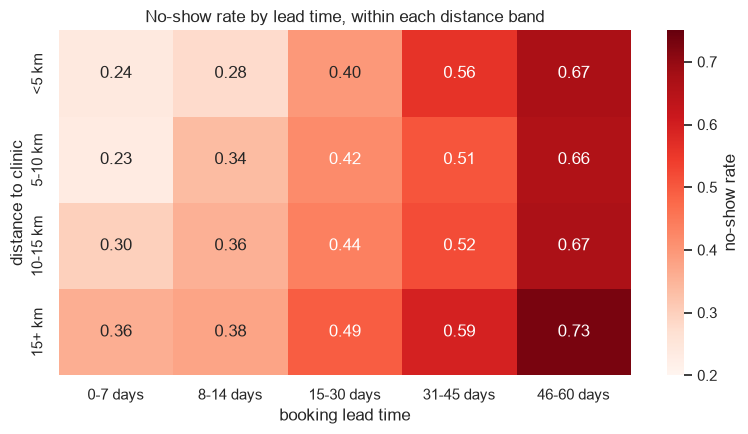

In [26]:
known = analysis[analysis["distance_known"]]
lead_order = ["0-7 days", "8-14 days", "15-30 days", "31-45 days", "46-60 days"]
dist_order = ["<5 km", "5-10 km", "10-15 km", "15+ km"]

pivot = known.pivot_table(index="distance_band", columns="lead_time_band",
                           values="is_no_show", aggfunc="mean", observed=True)
pivot = pivot.reindex(index=dist_order, columns=lead_order)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds", vmin=0.2, vmax=0.75,
            cbar_kws={"label": "no-show rate"}, ax=ax)
ax.set_title("No-show rate by lead time, within each distance band")
ax.set_xlabel("booking lead time")
ax.set_ylabel("distance to clinic")
plt.tight_layout()
plt.savefig(FIG_DIR / "confound_leadtime_within_distance.png", dpi=150)
plt.show()


Read any row left to right and the rate climbs steadily, from roughly 0.24 to 0.36 on the left up to 0.66 to 0.73 on the right. Whether a patient lives close or far, booking further ahead still raises the no-show rate by about the same amount. The lead-time effect is real and independent of distance.

### 4.3 Does the distance effect survive once lead time is held constant?

The same thing in reverse: does "15+ km patients miss more" hold within every lead-time group, or was it only true for one slice?

In [27]:
pivot2 = known.pivot_table(index="lead_time_band", columns="distance_band",
                            values="is_no_show", aggfunc="mean", observed=True)
pivot2 = pivot2.reindex(index=lead_order, columns=dist_order)
pivot2.round(3)


distance_band,<5 km,5-10 km,10-15 km,15+ km
lead_time_band,,,,
0-7 days,0.241,0.234,0.300,0.359
8-14 days,0.278,0.337,0.356,0.377
15-30 days,0.396,0.417,0.437,0.494
31-45 days,0.560,0.507,0.520,0.593
46-60 days,0.669,0.661,0.667,0.730


Read any row left to right and the `15+ km` column is the highest, or close to it, in every lead-time group, by roughly 5 to 13 points. Living far from the clinic adds no-show risk on top of whatever the lead-time risk already is. It is not an illusion from far patients happening to book earlier. The distance effect is real and independent too, even though it is the weaker of the two.

### 4.4 Does the prior-no-show effect survive once lead time is held constant?

Last check: is "patients with more prior no-shows miss more" just another way of saying "patients who book far ahead miss more", in case the two overlap heavily? Lead time is split into short (21 days or less) and long (more than 21 days), and the prior-no-show staircase is checked inside each.

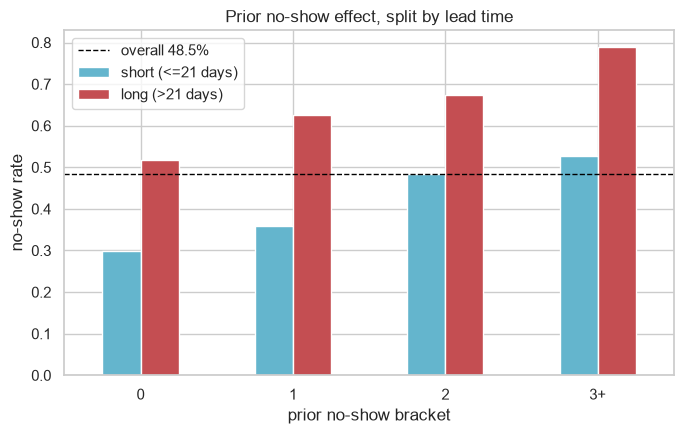

prior_no_show_bracket,0,1,2,3+
lead_coarse,,,,
short (<=21 days),0.299,0.360,0.484,0.528
long (>21 days),0.517,0.625,0.673,0.789


In [28]:
analysis["lead_coarse"] = pd.cut(analysis["booking_lead_days"], bins=[-1, 21, 60],
                                  labels=["short (<=21 days)", "long (>21 days)"])
bracket_order = ["0", "1", "2", "3+"]

fig, ax = plt.subplots(figsize=(7, 4.5))
tab = analysis.groupby(["lead_coarse", "prior_no_show_bracket"], observed=True)["is_no_show"].mean().unstack()
tab = tab.reindex(columns=bracket_order)
tab.T.plot(kind="bar", ax=ax, color=["#64B5CD", "#C44E52"])
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"overall {overall_rate:.1%}")
ax.set_ylabel("no-show rate")
ax.set_xlabel("prior no-show bracket")
ax.set_title("Prior no-show effect, split by lead time")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="")
plt.tight_layout()
plt.savefig(FIG_DIR / "confound_priornoshow_within_leadtime.png", dpi=150)
plt.show()

tab.round(3)


Both bars climb from bracket "0" to "3+", so the staircase holds in the short-lead group and the long-lead group. The "long" bar also sits above the "short" bar at every bracket, which is the lead-time effect and the prior-history effect adding on top of each other rather than one hiding the other. A patient who books far ahead and has missed before is the highest risk of all, at 78.9% here. This effect is real and independent too.

### 4.5 Confounding check: conclusion

All three of Week 4's flagged variables passed:

| Variable pair | Correlated with each other? | Effect survives the check? |
|---|---|---|
| Lead time and distance | No (correlation near 0) | Both hold independently |
| Lead time and prior no-shows | Effects add, not confounded | Both hold independently, and combine |

`booking_lead_days`, `distance_to_clinic_km`, and `previous_no_shows` are three separate risk factors, not one signal counted three times. That gives more confidence in the five KPIs built on them, and hands the Data Science track three features that each carry their own weight. This was Week 4's second Week 5 job, and it is done.

## 5. KPI development

A KPI is one number the clinic can watch over time to see whether things are improving. A good one is easy to calculate the same way every time, tied to a decision someone can actually make, and able to move when that decision changes.

Week 4 defined and justified five KPIs but did not calculate them, since the Week 4 rules did not allow it. This section calculates all five, using the segments built in Section 2 and checked in Sections 3 and 4.

### KPI 1: No-Show Rate by Prior No-Show Bracket

- **Definition.** The share of appointments that end in a no-show, grouped by how many times that patient has no-showed before (0, 1, 2, or 3+).
- **Why it matters.** It tests whether history repeats. If it does, the clinic can flag high-risk patients before the appointment and treat those bookings differently.
- **Business question (Q1).** Does a patient's prior no-show history predict whether they miss the next appointment?

In [29]:
bracket_order = ["0", "1", "2", "3+"]
kpi1 = analysis.groupby("prior_no_show_bracket", observed=True)["is_no_show"].agg(
    no_show_rate="mean", n_appointments="count").reindex(bracket_order)
kpi1["no_show_rate"] = kpi1["no_show_rate"].round(3)
kpi1


,no_show_rate,n_appointments
prior_no_show_bracket,,
0,0.435,2921
1,0.535,1548
2,0.594,438
3+,0.688,93


The rate rises from 43.5% at no prior no-shows to 68.8% at three or more, a 25-point gap. This is a clean KPI to run: it needs only something the clinic already holds, each patient's history, and it points straight at an action, a high-risk flag on the booking screen for anyone in the "2" or "3+" bracket. The "3+" bracket has only 93 appointments, so its exact figure should be watched over more data before it is treated as fixed, but the direction is steady.

### KPI 2: No-Show Rate by Booking Lead-Time Band

- **Definition.** The share of appointments that end in a no-show, grouped by how many days ahead the appointment was booked.
- **Why it matters.** It is directly actionable. If the clinic caps how far ahead a booking can be made, or adds a reconfirmation step for far-out bookings, this KPI shows whether it worked.
- **Business question (Q2).** Does booking lead time affect the no-show rate, and is there a point where the risk jumps?

In [30]:
lead_order = ["0-7 days", "8-14 days", "15-30 days", "31-45 days", "46-60 days"]
kpi2 = analysis.groupby("lead_time_band", observed=True)["is_no_show"].agg(
    no_show_rate="mean", n_appointments="count").reindex(lead_order)
kpi2["no_show_rate"] = kpi2["no_show_rate"].round(3)
kpi2


,no_show_rate,n_appointments
lead_time_band,,
0-7 days,0.278,640
8-14 days,0.336,602
15-30 days,0.432,1333
31-45 days,0.538,1258
46-60 days,0.677,1167


The rate climbs from 27.8% (booked within a week) to 67.7% (booked 46 to 60 days out). This is the strongest and cleanest KPI of the five. There is no single sharp cliff; the climb is steady through every band. So instead of one threshold, the recommendation is graduated: treat 31+ day bookings as needing a reconfirmation step, since that is where the rate crosses 50% and a miss becomes more likely than not.

### KPI 3: No-Show Rate by Distance Band

- **Definition.** The share of appointments that end in a no-show, grouped by how far the patient lives from the clinic.
- **Why it matters.** It tracks whether distance-based support such as transport help or a telehealth option closes the gap between near and far patients.
- **Business question (Q3).** Does distance affect attendance, and are some distance bands worse than others?
- **Data note.** Calculated on the 4,910 of 5,000 appointments (98.2%) that have a distance recorded. The other 90 rows are excluded rather than guessed at, per the Section 2 decision.

In [31]:
dist_order = ["<5 km", "5-10 km", "10-15 km", "15+ km"]
known = analysis[analysis["distance_known"]]
kpi3 = known.groupby("distance_band", observed=True)["is_no_show"].agg(
    no_show_rate="mean", n_appointments="count").reindex(dist_order)
kpi3["no_show_rate"] = kpi3["no_show_rate"].round(3)
kpi3


,no_show_rate,n_appointments
distance_band,,
<5 km,0.465,1156
5-10 km,0.465,1692
10-15 km,0.485,1132
15+ km,0.541,930


The under 5 km, 5 to 10 km, and 10 to 15 km bands are all close together (46.5% to 48.5%). Distance only starts to matter at 15+ km, where the rate jumps to 54.1%. So this is not a "the further, the worse" line; it is a specific "too far" point. A transport or telehealth offer aimed just at the 15+ km group (930 appointments, 18.9% of the rows with a known distance) would land exactly where the effect is, instead of spreading a costly intervention across everyone.

### KPI 4: Wasted Slot Rate, split by reminder status

- **Definition.** No-shows as a share of all scheduled appointments, in other words how much appointment capacity is wasted, split by whether a reminder was sent.
- **Why it matters.** This is the headline KPI. It answers the scenario's stated cost, "inefficient use of appointment slots", directly, and the reminder split folds in Q4 without a separate KPI.
- **Business question (Q4 and the central project question).** Does a reminder measurably reduce no-shows, and how much capacity is wasted overall?

In [32]:
overall_wasted = analysis["is_no_show"].mean()
kpi4 = analysis.groupby("reminder_sent", observed=True)["is_no_show"].agg(
    wasted_slot_rate="mean", n_appointments="count").reindex(["No", "Yes"])
kpi4["wasted_slot_rate"] = kpi4["wasted_slot_rate"].round(3)

print(f"Overall Wasted Slot Rate (all appointments): {overall_wasted:.1%}")
kpi4


Overall Wasted Slot Rate (all appointments): 48.5%


,wasted_slot_rate,n_appointments
reminder_sent,,
No,0.514,1366
Yes,0.474,3634


48.5% of all scheduled slots are wasted on a no-show. That is the headline number for the whole project: about one slot in two booked never gets used. Split by reminder status, no reminder is 51.4% wasted and a reminder sent is 47.4%. Reminders help by about four points, worth keeping, but nowhere near enough on their own to solve the problem the scenario describes. Most of the fix has to come from the levers in KPIs 1 to 3, not from reminder messaging.

### KPI 5: Cancellation-to-No-Show Ratio

- **Definition.** The number of proper cancellations divided by the number of no-shows. A cancellation means the patient warned the clinic in advance. A no-show means they simply did not come.
- **Why it matters.** It tracks whether missed slots are shifting from silent no-shows to proper cancellations. A rising ratio is a good sign even before attendance itself improves, because a cancelled slot can be offered to someone else and a no-show slot cannot.
- **Business question (Q5).** Should cancellations be measured separately from no-shows?

In [33]:
n_cancelled = (analysis["appointment_outcome"] == "Cancelled").sum()
n_no_show   = (analysis["appointment_outcome"] == "No-Show").sum()
overall_ratio = n_cancelled / n_no_show

print(f"Overall Cancellation-to-No-Show Ratio: {n_cancelled} / {n_no_show} = {overall_ratio:.3f}")
print(f"(roughly 1 proper cancellation for every {1/overall_ratio:.1f} no-shows)")
print()

missed = analysis[analysis["appointment_outcome"].isin(["Cancelled", "No-Show"])]
kpi5_by_lead = missed.groupby(["lead_time_band", "appointment_outcome"], observed=True).size().unstack(fill_value=0)
kpi5_by_lead = kpi5_by_lead.reindex(lead_order)
kpi5_by_lead["cancel_to_noshow_ratio"] = (kpi5_by_lead["Cancelled"] / kpi5_by_lead["No-Show"]).round(3)
kpi5_by_lead


Overall Cancellation-to-No-Show Ratio: 263 / 2423 = 0.109
(roughly 1 proper cancellation for every 9.2 no-shows)



appointment_outcome,Cancelled,No-Show,cancel_to_noshow_ratio
lead_time_band,,,
0-7 days,36,178,0.202
8-14 days,28,202,0.139
15-30 days,68,576,0.118
31-45 days,71,677,0.105
46-60 days,60,790,0.076


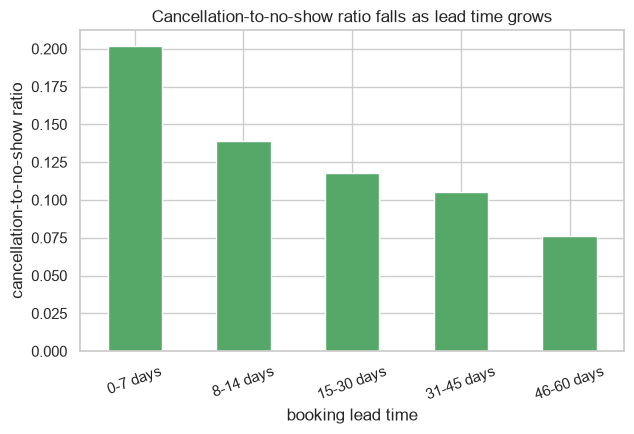

In [34]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
kpi5_by_lead["cancel_to_noshow_ratio"].plot(kind="bar", ax=ax, color="#55A868")
ax.set_ylabel("cancellation-to-no-show ratio")
ax.set_xlabel("booking lead time")
ax.set_title("Cancellation-to-no-show ratio falls as lead time grows")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "kpi5_cancel_ratio_by_leadtime.png", dpi=150)
plt.show()


Overall there are 0.109 cancellations for every no-show, so silent no-shows outnumber proper cancellations by roughly nine to one. The lead-time breakdown shows something the overall figure hides: the ratio falls as lead time grows, from 0.202 (booked within a week) to 0.076 (booked 46 to 60 days out). Patients who booked far ahead are less likely to call and cancel and more likely to just not show up. This backs Week 4's position that Cancelled and No-Show must stay separate, since merging them would bury this pattern. It also points at a specific fix: a reconfirmation prompt closer to the appointment date for long-lead bookings, giving patients an easy way to turn a silent no-show into a proper, rebookable cancellation.

### 5.1 KPI summary

| # | KPI | Value / range | Question |
|---|---|---|---|
| 1 | No-Show Rate by Prior No-Show Bracket | 43.5% to 68.8% | Q1 |
| 2 | No-Show Rate by Booking Lead-Time Band | 27.8% to 67.7% | Q2 |
| 3 | No-Show Rate by Distance Band | 46.5% (near) to 54.1% (15+ km) | Q3 |
| 4 | Wasted Slot Rate, by reminder status | 48.5% overall (51.4% no reminder, 47.4% reminded) | Q4 and central question |
| 5 | Cancellation-to-No-Show Ratio | 0.109 overall, falling with lead time (0.202 to 0.076) | Q5 |

All five were identified in Week 4 and are now calculated, charted, and interpreted in Week 5, which is what the brief asks for: moving from "what should we do" to "let's begin doing it".

## 6. Dashboard

A dashboard is just the important charts on one page, so a clinic manager can take it in at a glance instead of scrolling the whole notebook. This one is a single image with six panels: the headline number, then one per KPI. Week 4 named Power BI or Tableau for a later, more polished version. This notebook-built version is the initial dashboard the brief asks for, built with the same tool as the rest of the analysis so it stays reproducible. A Power BI version is also included in `outputs/dashboard/`.

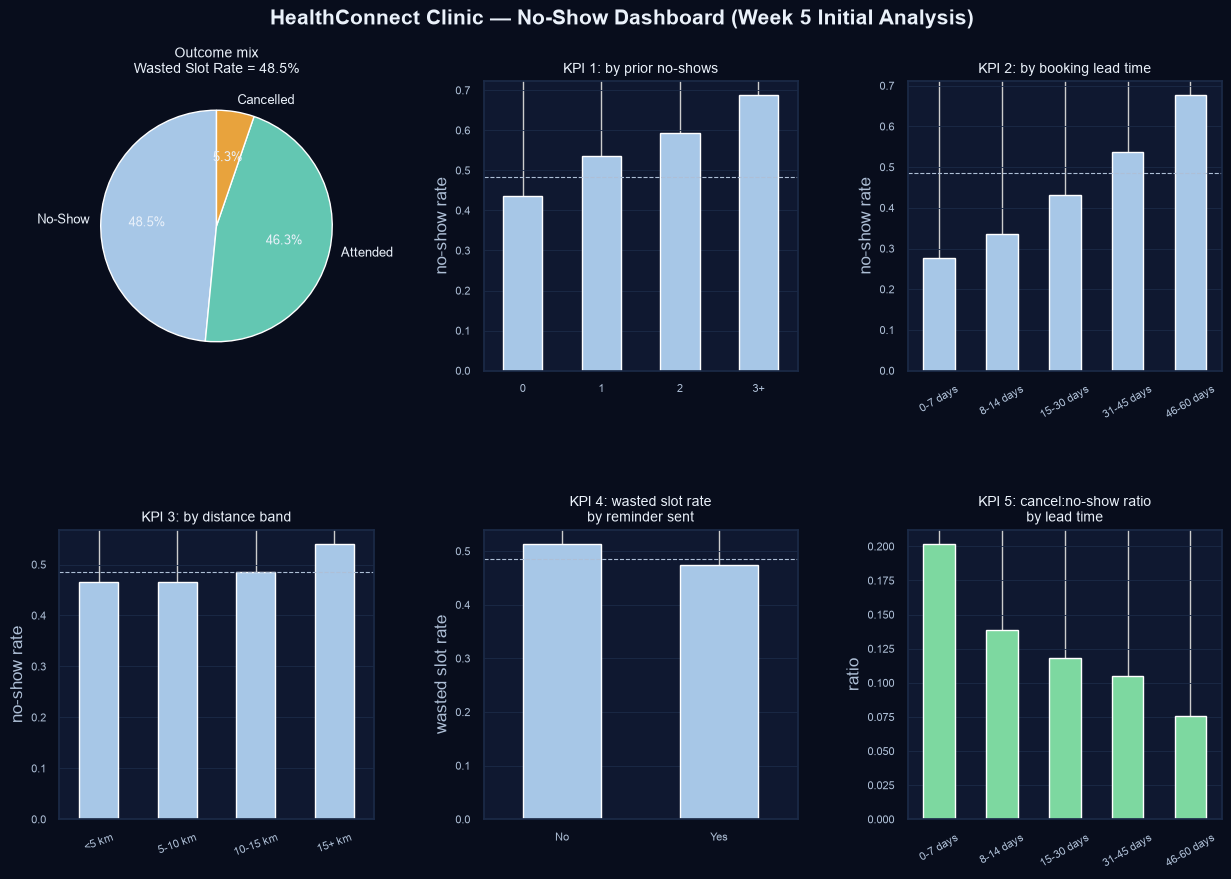

Dashboard saved to: C:\Users\hilla\OneDrive\Desktop\AnalystLab\week 5\outputs\dashboard\HealthConnect_Week5_Dashboard_Python.png


In [35]:
# Dark-blue theme, matching the Power BI dashboard (.pbix)
BG      = "#080D1C"   # page background
PANEL   = "#0F1830"   # panel background
BAR     = "#A7C7E7"   # bar colour
BAR_ALT = "#7DD8A0"   # accent for the "higher is better" KPI
TEXT    = "#EAF1FA"   # primary text
MUTED   = "#AEBFD6"   # axis text
GRID    = "#1B2A47"   # gridlines

def style(ax):
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.yaxis.label.set_color(MUTED)
    ax.title.set_color(TEXT)
    ax.grid(axis="y", color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)

fig = plt.figure(figsize=(15, 9), facecolor=BG)
fig.suptitle("HealthConnect Clinic — No-Show Dashboard (Week 5 Initial Analysis)",
             fontsize=15, fontweight="bold", color=TEXT)
gs = fig.add_gridspec(2, 3, hspace=0.55, wspace=0.35, top=0.90, bottom=0.08)

# --- Panel 1: outcome mix ---
ax0 = fig.add_subplot(gs[0, 0]); ax0.set_facecolor(PANEL)
mix = analysis["appointment_outcome"].value_counts()
pie_colors = {"No-Show": "#A7C7E7", "Attended": "#63C7B2", "Cancelled": "#E8A33D"}
wedges, texts, autotexts = ax0.pie(
    mix, labels=mix.index, autopct="%1.1f%%",
    colors=[pie_colors[k] for k in mix.index], startangle=90,
    textprops={"fontsize": 9, "color": TEXT})
ax0.set_title(f"Outcome mix\nWasted Slot Rate = {overall_rate:.1%}", fontsize=10, color=TEXT)

# --- Panel 2: KPI1 - prior no-show bracket ---
ax1 = fig.add_subplot(gs[0, 1])
kpi1["no_show_rate"].plot(kind="bar", ax=ax1, color=BAR)
ax1.axhline(overall_rate, color=MUTED, linestyle="--", linewidth=0.8)
ax1.set_title("KPI 1: by prior no-shows", fontsize=10)
ax1.set_xlabel(""); ax1.set_ylabel("no-show rate"); ax1.tick_params(axis="x", rotation=0)
style(ax1)

# --- Panel 3: KPI2 - lead time band ---
ax2 = fig.add_subplot(gs[0, 2])
kpi2["no_show_rate"].plot(kind="bar", ax=ax2, color=BAR)
ax2.axhline(overall_rate, color=MUTED, linestyle="--", linewidth=0.8)
ax2.set_title("KPI 2: by booking lead time", fontsize=10)
ax2.set_xlabel(""); ax2.set_ylabel("no-show rate"); ax2.tick_params(axis="x", rotation=30)
style(ax2)

# --- Panel 4: KPI3 - distance band ---
ax3 = fig.add_subplot(gs[1, 0])
kpi3["no_show_rate"].plot(kind="bar", ax=ax3, color=BAR)
ax3.axhline(overall_rate, color=MUTED, linestyle="--", linewidth=0.8)
ax3.set_title("KPI 3: by distance band", fontsize=10)
ax3.set_xlabel(""); ax3.set_ylabel("no-show rate"); ax3.tick_params(axis="x", rotation=20)
style(ax3)

# --- Panel 5: KPI4 - reminder cut ---
ax4 = fig.add_subplot(gs[1, 1])
kpi4["wasted_slot_rate"].reindex(["No", "Yes"]).plot(kind="bar", ax=ax4, color=BAR)
ax4.axhline(overall_rate, color=MUTED, linestyle="--", linewidth=0.8)
ax4.set_title("KPI 4: wasted slot rate\nby reminder sent", fontsize=10)
ax4.set_xlabel(""); ax4.set_ylabel("wasted slot rate"); ax4.tick_params(axis="x", rotation=0)
style(ax4)

# --- Panel 6: KPI5 - cancel:no-show ratio by lead time ---
ax5 = fig.add_subplot(gs[1, 2])
kpi5_by_lead["cancel_to_noshow_ratio"].plot(kind="bar", ax=ax5, color=BAR_ALT)
ax5.set_title("KPI 5: cancel:no-show ratio\nby lead time", fontsize=10)
ax5.set_xlabel(""); ax5.set_ylabel("ratio"); ax5.tick_params(axis="x", rotation=30)
style(ax5)

DASHBOARD_PATH = OUTPUT_DIR / "dashboard" / "HealthConnect_Week5_Dashboard_Python.png"
plt.savefig(DASHBOARD_PATH, dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

print("Dashboard saved to:", DASHBOARD_PATH.resolve())


Reading it at a glance:

- Top-left: the headline. Nearly half of every slot (48.5%) is lost to a no-show, and only 5.3% are properly cancelled.
- Top-middle and top-right: the two strongest KPIs, both climbing steeply, prior history and booking lead time.
- Bottom-left: distance only bites at the far end, 15+ km.
- Bottom-middle: reminders help, but only a little.
- Bottom-right: the further ahead someone books, the less likely they are to cancel properly rather than silently not show.

The dashed line in the first five panels marks the 48.5% baseline, so any bar well above or below it is a real finding. This single image is the one thing a clinic manager could review without opening the notebook.

## 7. Business insights

Five insights, each tied to a number from above, with what it could mean for how the clinic runs.

In [36]:
double_risk = analysis[(analysis["previous_no_shows"] >= 2) & (analysis["booking_lead_days"] >= 31)]
print(f"'Double-risk' group (2+ prior no-shows AND booked 31+ days out): "
      f"{len(double_risk):,} appointments ({len(double_risk)/len(analysis):.1%} of all bookings)")
print(f"No-show rate within this group: {double_risk['is_no_show'].mean():.1%}")


'Double-risk' group (2+ prior no-shows AND booked 31+ days out): 233 appointments (4.7% of all bookings)
No-show rate within this group: 73.0%


**Insight 1: a small "double-risk" group loses an outsized share of capacity.** Appointments where the patient has two or more prior no-shows and booked 31+ days ahead are only 4.7% of all bookings (233 of 5,000), but 73.0% of them are missed, roughly 1.5 times the clinic-wide rate. A targeted step for this group, such as a confirmation call, a priority reminder, or a shorter allowed booking window, could recover a real number of slots without changing anything for the other 95% of patients.

**Insight 2: booking lead time is the biggest lever the clinic actually controls.** The no-show rate more than doubles from 27.8% (booked within a week) to 67.7% (booked 46 to 60 days out), a bigger swing than any other variable. A patient's history cannot be changed and neither can where they live, but how far ahead a slot can be booked is a policy decision, for example capping standard bookings at 30 days or adding a reconfirmation step beyond that.

**Insight 3: the reminder programme works, but it is not enough on its own.** Reminders cut the no-show rate by about four points (51.4% to 47.4%). That is a real effect, not nothing, but it is far smaller than the gap from lead time or prior history. Keep sending reminders, since there is no reason to stop, but do not expect changes to the reminders alone to fix the problem. The effort is better spent on lead-time policy and history-based flagging.

**Insight 4: long-lead-time patients quietly disappear instead of cancelling.** The cancellation-to-no-show ratio falls from 0.202 (booked within a week) to 0.076 (booked 46 to 60 days out), so patients who booked far ahead are relatively less than half as likely to warn the clinic when they cannot make it. A reconfirmation prompt partway through a long lead time, at the 30-day mark say, gives these patients an easy way to turn a silent no-show into a proper, rebookable cancellation.

**Insight 5: distance is a cliff, not a slope, so support should be targeted.** No-show rates are nearly flat from under 5 km through 10 to 15 km (46.5% to 48.5%), then jump to 54.1% at 15+ km (930 appointments, 18.9% of those with a known distance). A transport subsidy or telehealth option aimed only at the 15+ km group puts the resource where the effect actually is, rather than spreading it thin across every patient.

## 8. Business recommendations

1. **Flag high-risk bookings when they are made.** Combine prior no-show count and lead time into a simple risk flag (KPI 1 and KPI 2, confirmed independent in Section 4), so staff can put confirmation calls into the riskiest 5% of bookings first.
2. **Set a lead-time policy.** Treat bookings of 31+ days as needing a mid-way reconfirmation, since that is where the no-show rate crosses 50%.
3. **Add a reconfirmation step for long-lead bookings specifically**, to turn silent no-shows into proper cancellations (Insight 4), which can be rebooked.
4. **Aim distance-based support at the 15+ km group only** (Insight 5), not a clinic-wide transport or telehealth rollout.
5. **Keep the reminder programme running**, but treat it as support, not the main fix.

## 9. Limitations

- These are associations, not causes. No statistical model has been fitted; Section 4 was a check, not a model. Causal and predictive modelling is the Data Science track's job.
- The dataset is synthetic and includes appointments dated into mid-2026, so it is simulated for training. The patterns hold within this data but are not validated against a real clinic.
- The "3+" prior no-show bracket (93 rows) and the exact edges of the 15+ km distance band rest on smaller samples than the rest of the data. They should be monitored as more data arrives rather than treated as fixed.
- The distance KPIs run on 98.2% of appointments, with 90 rows excluded for missing distance rather than imputed. That is a deliberate, documented choice.
- Patients repeat across rows (1,696 patients, 5,000 appointments), so the appointments are not fully independent of each other. The rate calculations here do not adjust for that.